# 24. Capstone AI-Assisted Causal Project

This capstone assembles the full AI-for-causal-inference workflow. We start with an industry decision, build an estimand card, screen variables, choose a design, run diagnostics, estimate effects, stress-test assumptions, generate a report, audit AI outputs, and compare model families.

The project is intentionally realistic: a company enabled an AI sales assistant for some sales reps and wants to know whether to expand it. Treatment was not randomized, adoption was targeted, and the data contain tempting post-treatment variables. This is exactly the kind of setting where AI assistance can help, but only if the workflow is structured and audited.

## Learning Goals

By the end of this capstone, you should be able to:

- Turn a business decision into a causal project contract.
- Build a variable-timing screen and defensible adjustment set.
- Compare naive, regression-adjusted, IPW, and AIPW estimates.
- Diagnose overlap, balance, guardrails, and estimator stability.
- Package evidence for AI-assisted report generation.
- Audit AI-generated recommendations for hallucination and overclaiming.
- Run role-style and all-model comparisons with memory cleanup.
- Explain why end-to-end AI causal workflows remain brittle even when each component looks reasonable.

## Live Model Note

Capstone notebooks are the most brittle notebooks in this course because many things can fail at once: model loading, structured parsing, variable-role reasoning, estimator diagnostics, report language, and all-model comparison. A model can be right about the business question and wrong about the adjustment set. It can produce a beautiful report that hides a bad control. It can pass one rerun and fail another.

That brittleness is part of the lesson. The workflow below treats AI as an assistant whose outputs must be structured, scored, redlined, and reviewed by a human causal owner. We also clear loaded model memory between model-family calls to reduce GPU fragility.

## 1. Setup

The capstone uses standard Python tools plus the shared local-LLM helpers from earlier notebooks. Live model calls are optional; the deterministic analysis is fully runnable without them.

In [1]:
import json
import re
import sys
import warnings
from copy import deepcopy
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from pydantic import BaseModel, Field

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'local_llm.py').exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /home/apex/Documents/portfolio


In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

MODEL_ID = 'Qwen/Qwen2.5-14B-Instruct'
MAX_NEW_TOKENS = 2400
COMPACT_MAX_NEW_TOKENS = 950
TEMPERATURE = 0.0
SEED = 224
MODEL_COMPARISON_CASE_LIMIT = 3

try:
    import torch
    print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
except Exception as exc:
    print(f'Torch availability check failed: {exc}')

CUDA available to this kernel: True


In [3]:
try:
    from notebooks._shared.local_llm import DEFAULT_MODELS_TO_COMPARE
except Exception:
    DEFAULT_MODELS_TO_COMPARE = [('Qwen 14B', MODEL_ID, 'strong local analysis')]

MODELS_TO_COMPARE = DEFAULT_MODELS_TO_COMPARE
pd.DataFrame(MODELS_TO_COMPARE, columns=['label', 'model_id', 'role'])

,label,model_id,role
0,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test
1,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default
2,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis
3,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison
5,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison
6,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison
7,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison
8,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline


## 2. Business Project Brief

The company piloted an AI sales assistant that drafts follow-up messages, summarizes account history, and suggests next actions. Sales leadership wants to expand it to all reps if it increases qualified pipeline without harming customer experience.

The tricky part: enablement was targeted. Managers enabled the assistant first for reps with higher account readiness, stronger adoption likelihood, and available training capacity. That makes this an observational causal project, not a randomized experiment.

In [4]:
project_brief = {
    'project_id': 'ai_sales_assistant_capstone_v1',
    'decision': 'Should the company expand the AI sales assistant to all eligible sales reps?',
    'unit': 'rep_account_month',
    'treatment': 'ai_assistant_enabled',
    'primary_outcome': 'qualified_pipeline_created',
    'secondary_outcome': 'pipeline_value_30d',
    'guardrail_outcomes': ['customer_complaint_30d', 'discount_rate_30d'],
    'time_horizon': '30 days after account-month eligibility',
    'assignment_process': 'Managers enabled the assistant first for reps with high readiness, high-volume accounts, and available onboarding capacity.',
    'known_risks': [
        'Enablement was targeted rather than randomized.',
        'AI activity metrics after enablement are post-treatment variables.',
        'Revenue-facing outcomes can move with seasonality and account mix.',
        'Expansion may increase discounting or customer complaints.',
    ],
}

print(json.dumps(project_brief, indent=2))

{
  "project_id": "ai_sales_assistant_capstone_v1",
  "decision": "Should the company expand the AI sales assistant to all eligible sales reps?",
  "unit": "rep_account_month",
  "treatment": "ai_assistant_enabled",
  "primary_outcome": "qualified_pipeline_created",
  "secondary_outcome": "pipeline_value_30d",
  "guardrail_outcomes": [
    "customer_complaint_30d",
    "discount_rate_30d"
  ],
  "time_horizon": "30 days after account-month eligibility",
  "assignment_process": "Managers enabled the assistant first for reps with high readiness, high-volume accounts, and available onboarding capacity.",
  "known_risks": [
    "Enablement was targeted rather than randomized.",
    "AI activity metrics after enablement are post-treatment variables.",
    "Revenue-facing outcomes can move with seasonality and account mix.",
    "Expansion may increase discounting or customer complaints."
  ]
}


## 3. Synthetic Capstone Data

The data-generating process contains pre-treatment confounding, a real positive effect, heterogeneous response, post-treatment usage, and guardrails. We keep the synthetic truth for teaching, but a real analysis would not have access to it.

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def simulate_sales_assistant_data(n=7200, seed=SEED):
    rng = np.random.default_rng(seed)
    region = rng.choice(['north_america', 'emea', 'apac', 'latam'], size=n, p=[0.45, 0.27, 0.18, 0.10])
    segment = rng.choice(['smb', 'mid_market', 'enterprise'], size=n, p=[0.42, 0.38, 0.20])
    month = rng.integers(1, 13, size=n)

    region_effect = {'north_america': 0.15, 'emea': 0.02, 'apac': -0.06, 'latam': -0.12}
    segment_effect = {'smb': -0.20, 'mid_market': 0.08, 'enterprise': 0.32}

    rep_tenure_months = rng.gamma(shape=3.0, scale=7.0, size=n).clip(1, 96)
    account_size = np.exp(rng.normal(4.5, 0.70, size=n)) * np.select(
        [segment == 'enterprise', segment == 'mid_market'],
        [4.8, 2.0],
        default=1.0,
    )
    prior_pipeline_90d = np.maximum(0, rng.normal(55 + 0.035 * account_size + 1.2 * rep_tenure_months, 35, size=n))
    prior_email_volume = rng.poisson(np.clip(12 + 0.035 * prior_pipeline_90d + 0.4 * rep_tenure_months, 1, 80))
    rep_readiness_score = sigmoid(
        -0.7
        + 0.055 * rep_tenure_months
        + 0.018 * prior_email_volume
        + 0.10 * (segment == 'enterprise')
        + rng.normal(0, 0.65, size=n)
    )
    manager_capacity_score = sigmoid(rng.normal(0.0, 0.9, size=n) + 0.2 * (region == 'north_america'))

    treatment_logit = (
        -1.55
        + 2.3 * rep_readiness_score
        + 0.9 * manager_capacity_score
        + 0.25 * (segment == 'enterprise')
        + 0.10 * (region == 'north_america')
        + 0.004 * prior_pipeline_90d
    )
    true_propensity = sigmoid(treatment_logit)
    ai_assistant_enabled = rng.binomial(1, true_propensity)

    base_pipeline_logit = (
        -1.05
        + 0.75 * rep_readiness_score
        + 0.006 * prior_pipeline_90d
        + 0.0025 * account_size
        + np.vectorize(region_effect.get)(region)
        + np.vectorize(segment_effect.get)(segment)
        + 0.06 * np.sin(2 * np.pi * month / 12)
    )
    treatment_effect_logit = 0.34 + 0.15 * (rep_readiness_score > 0.70) - 0.05 * (segment == 'smb')
    p0 = sigmoid(base_pipeline_logit)
    p1 = sigmoid(base_pipeline_logit + treatment_effect_logit)
    qualified_pipeline_created = rng.binomial(1, np.where(ai_assistant_enabled == 1, p1, p0))

    ai_messages_generated_after_enablement = rng.poisson(
        np.clip(ai_assistant_enabled * (5 + 12 * rep_readiness_score + 0.05 * prior_email_volume), 0, 40)
    )
    pipeline_value_30d = np.maximum(
        0,
        qualified_pipeline_created * (0.12 * account_size + 280 * (segment == 'enterprise') + 95 * (segment == 'mid_market'))
        + 65 * ai_assistant_enabled
        + rng.normal(0, 75, size=n),
    )
    complaint_logit = -3.4 + 0.18 * ai_assistant_enabled + 0.04 * ai_messages_generated_after_enablement + 0.12 * (segment == 'enterprise')
    customer_complaint_30d = rng.binomial(1, sigmoid(complaint_logit))
    discount_rate_30d = np.clip(
        rng.normal(0.08 + 0.012 * ai_assistant_enabled + 0.01 * (segment == 'enterprise'), 0.035, size=n),
        0,
        0.35,
    )

    return pd.DataFrame({
        'row_id': np.arange(n),
        'region': region,
        'segment': segment,
        'month': month,
        'rep_tenure_months': rep_tenure_months,
        'account_size': account_size,
        'prior_pipeline_90d': prior_pipeline_90d,
        'prior_email_volume': prior_email_volume,
        'rep_readiness_score': rep_readiness_score,
        'manager_capacity_score': manager_capacity_score,
        'ai_assistant_enabled': ai_assistant_enabled,
        'ai_messages_generated_after_enablement': ai_messages_generated_after_enablement,
        'qualified_pipeline_created': qualified_pipeline_created,
        'pipeline_value_30d': pipeline_value_30d,
        'customer_complaint_30d': customer_complaint_30d,
        'discount_rate_30d': discount_rate_30d,
        'true_expected_effect': p1 - p0,
    })


df = simulate_sales_assistant_data()
df.head()

,row_id,region,segment,month,rep_tenure_months,account_size,prior_pipeline_90d,prior_email_volume,rep_readiness_score,manager_capacity_score,ai_assistant_enabled,ai_messages_generated_after_enablement,qualified_pipeline_created,pipeline_value_30d,customer_complaint_30d,discount_rate_30d,true_expected_effect
0,0,emea,smb,11,18.993379,106.492576,77.223041,30,0.743474,0.588200,0,0,0,1.102941,0,0.115940,0.107922
1,1,north_america,smb,3,15.435945,43.601307,0.000000,18,0.598698,0.588618,1,14,0,56.401793,0,0.111728,0.070367
2,2,emea,smb,6,27.289013,139.423344,72.766319,16,0.494988,0.531616,1,17,0,97.508842,0,0.065960,0.072282
3,3,north_america,smb,7,22.307803,89.310346,55.154627,22,0.742558,0.401374,1,14,1,61.689052,0,0.127857,0.108471
4,4,apac,enterprise,7,2.288778,486.468304,70.975926,19,0.716149,0.802218,1,17,1,336.993169,1,0.163899,0.068406


In [6]:
observed_summary = (
    df.assign(enabled_label=lambda d: np.where(d['ai_assistant_enabled'] == 1, 'enabled', 'not enabled'))
    .groupby('enabled_label')
    .agg(
        rows=('row_id', 'size'),
        qualified_pipeline_created=('qualified_pipeline_created', 'mean'),
        pipeline_value_30d=('pipeline_value_30d', 'mean'),
        customer_complaint_30d=('customer_complaint_30d', 'mean'),
        discount_rate_30d=('discount_rate_30d', 'mean'),
        rep_readiness_score=('rep_readiness_score', 'mean'),
        manager_capacity_score=('manager_capacity_score', 'mean'),
        prior_pipeline_90d=('prior_pipeline_90d', 'mean'),
    )
    .reset_index()
)

naive_effect = (
    df.loc[df['ai_assistant_enabled'] == 1, 'qualified_pipeline_created'].mean()
    - df.loc[df['ai_assistant_enabled'] == 0, 'qualified_pipeline_created'].mean()
)
true_ate = df['true_expected_effect'].mean()
observed_summary

,enabled_label,rows,qualified_pipeline_created,pipeline_value_30d,customer_complaint_30d,discount_rate_30d,rep_readiness_score,manager_capacity_score,prior_pipeline_90d
0,enabled,5002,0.722311,174.013484,0.074770,0.094568,0.700708,0.530016,92.588055
1,not enabled,2198,0.606460,98.976213,0.035487,0.082681,0.615041,0.502603,81.807032


In [7]:
pd.DataFrame([
    {'quantity': 'naive enabled-control difference', 'value': naive_effect},
    {'quantity': 'true expected ATE visible only in synthetic data', 'value': true_ate},
])

,quantity,value
0,naive enabled-control difference,0.115851
1,true expected ATE visible only in synthetic data,0.076648


## 4. Project Contract and Estimand Card

The first capstone artifact is a project contract. It constrains later AI outputs: the model should not invent a new treatment, shift the outcome, or turn an observational design into an experiment.

In [8]:
estimand_card = {
    'project_id': project_brief['project_id'],
    'decision': project_brief['decision'],
    'unit': project_brief['unit'],
    'treatment': project_brief['treatment'],
    'outcome': project_brief['primary_outcome'],
    'time_horizon': project_brief['time_horizon'],
    'estimand': 'Average effect of enabling the AI sales assistant on qualified pipeline creation among eligible rep-account-months',
    'comparison': 'The same eligible rep-account-months under no AI assistant enablement',
    'design_class': 'observational_adjustment',
    'key_assumption': 'Conditional exchangeability after observed pre-treatment adjustment',
    'must_not_claim': [
        'Do not call this randomized evidence.',
        'Do not control for AI messages generated after enablement.',
        'Do not recommend full rollout without guardrail review.',
    ],
}

print(json.dumps(estimand_card, indent=2))

{
  "project_id": "ai_sales_assistant_capstone_v1",
  "decision": "Should the company expand the AI sales assistant to all eligible sales reps?",
  "unit": "rep_account_month",
  "treatment": "ai_assistant_enabled",
  "outcome": "qualified_pipeline_created",
  "time_horizon": "30 days after account-month eligibility",
  "estimand": "Average effect of enabling the AI sales assistant on qualified pipeline creation among eligible rep-account-months",
  "comparison": "The same eligible rep-account-months under no AI assistant enablement",
  "design_class": "observational_adjustment",
  "key_assumption": "Conditional exchangeability after observed pre-treatment adjustment",
  "must_not_claim": [
    "Do not call this randomized evidence.",
    "Do not control for AI messages generated after enablement.",
    "Do not recommend full rollout without guardrail review."
  ]
}


## 5. Variable Timing Screen

The post-treatment AI activity variable is tempting because it predicts outcomes. It is also a bad control for estimating the total effect of enablement.

In [9]:
variable_dictionary = pd.DataFrame([
    {'variable': 'region', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'segment', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'month', 'timing': 'pre', 'role': 'seasonality_control', 'allowed_in_adjustment': True},
    {'variable': 'rep_tenure_months', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'account_size', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'prior_pipeline_90d', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'prior_email_volume', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'rep_readiness_score', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'manager_capacity_score', 'timing': 'pre', 'role': 'confounder', 'allowed_in_adjustment': True},
    {'variable': 'ai_assistant_enabled', 'timing': 'treatment', 'role': 'treatment', 'allowed_in_adjustment': False},
    {'variable': 'ai_messages_generated_after_enablement', 'timing': 'post', 'role': 'mediator_or_usage', 'allowed_in_adjustment': False},
    {'variable': 'qualified_pipeline_created', 'timing': 'post', 'role': 'primary_outcome', 'allowed_in_adjustment': False},
    {'variable': 'pipeline_value_30d', 'timing': 'post', 'role': 'secondary_outcome', 'allowed_in_adjustment': False},
    {'variable': 'customer_complaint_30d', 'timing': 'post', 'role': 'guardrail_outcome', 'allowed_in_adjustment': False},
    {'variable': 'discount_rate_30d', 'timing': 'post', 'role': 'guardrail_outcome', 'allowed_in_adjustment': False},
])

adjustment_set = variable_dictionary.loc[variable_dictionary['allowed_in_adjustment'], 'variable'].tolist()
post_treatment_variables = variable_dictionary.loc[variable_dictionary['timing'].eq('post'), 'variable'].tolist()
variable_dictionary

,variable,timing,role,allowed_in_adjustment
0,region,pre,confounder,True
1,segment,pre,confounder,True
2,month,pre,seasonality_control,True
3,rep_tenure_months,pre,confounder,True
4,account_size,pre,confounder,True
5,prior_pipeline_90d,pre,confounder,True
6,prior_email_volume,pre,confounder,True
7,rep_readiness_score,pre,confounder,True
8,manager_capacity_score,pre,confounder,True
9,ai_assistant_enabled,treatment,treatment,False


## 6. Balance and Overlap Diagnostics

The capstone uses a propensity model to diagnose overlap and construct IPW/AIPW estimates. In production, this step should be reviewed carefully; propensity models are not magic confounding removers.

In [10]:
def rhs(covariates):
    terms = []
    for covariate in covariates:
        if covariate in ['region', 'segment', 'month']:
            terms.append(f'C({covariate})')
        else:
            terms.append(covariate)
    return ' + '.join(terms)


def standardized_difference(data, variable, treatment='ai_assistant_enabled', weights=None):
    treated = data[treatment] == 1
    x1 = data.loc[treated, variable]
    x0 = data.loc[~treated, variable]
    if weights is None:
        m1, m0 = x1.mean(), x0.mean()
        v1, v0 = x1.var(ddof=1), x0.var(ddof=1)
    else:
        w1 = weights.loc[treated]
        w0 = weights.loc[~treated]
        m1 = np.average(x1, weights=w1)
        m0 = np.average(x0, weights=w0)
        v1 = np.average((x1 - m1) ** 2, weights=w1)
        v0 = np.average((x0 - m0) ** 2, weights=w0)
    pooled = np.sqrt((v1 + v0) / 2)
    return 0.0 if pooled == 0 or np.isnan(pooled) else float((m1 - m0) / pooled)


ps_formula = f"ai_assistant_enabled ~ {rhs(adjustment_set)}"
ps_model = smf.logit(ps_formula, data=df).fit(disp=False)
df_capstone = df.copy()
df_capstone['propensity'] = ps_model.predict(df_capstone).clip(0.02, 0.98)
df_capstone['ipw_weight'] = (
    df_capstone['ai_assistant_enabled'] / df_capstone['propensity']
    + (1 - df_capstone['ai_assistant_enabled']) / (1 - df_capstone['propensity'])
)

overlap = {
    'min_propensity': float(df_capstone['propensity'].min()),
    'max_propensity': float(df_capstone['propensity'].max()),
    'share_between_05_95': float(((df_capstone['propensity'] >= 0.05) & (df_capstone['propensity'] <= 0.95)).mean()),
    'effective_sample_size_ipw': float(df_capstone['ipw_weight'].sum() ** 2 / (df_capstone['ipw_weight'] ** 2).sum()),
}
overlap['status'] = 'pass' if overlap['share_between_05_95'] >= 0.95 else 'review'
print(json.dumps(overlap, indent=2))

{
  "min_propensity": 0.23244933930005748,
  "max_propensity": 0.9401834725453633,
  "share_between_05_95": 1.0,
  "effective_sample_size_ipw": 5362.045681722396,
  "status": "pass"
}


In [11]:
numeric_confounders = [
    'rep_tenure_months',
    'account_size',
    'prior_pipeline_90d',
    'prior_email_volume',
    'rep_readiness_score',
    'manager_capacity_score',
]

balance_rows = []
for variable in numeric_confounders:
    balance_rows.append({
        'variable': variable,
        'raw_std_diff': standardized_difference(df_capstone, variable),
        'weighted_std_diff': standardized_difference(df_capstone, variable, weights=df_capstone['ipw_weight']),
    })

balance_table = pd.DataFrame(balance_rows)
balance_table['raw_status'] = np.where(balance_table['raw_std_diff'].abs() <= 0.10, 'pass', 'review')
balance_table['weighted_status'] = np.where(balance_table['weighted_std_diff'].abs() <= 0.10, 'pass', 'review')
balance_table

,variable,raw_std_diff,weighted_std_diff,raw_status,weighted_status
0,rep_tenure_months,0.328984,-0.011364,review,pass
1,account_size,0.095445,-0.008091,pass,pass
2,prior_pipeline_90d,0.281279,-0.012470,review,pass
3,prior_email_volume,0.291887,-0.011018,review,pass
4,rep_readiness_score,0.481754,-0.009862,review,pass
5,manager_capacity_score,0.144151,-0.003312,review,pass


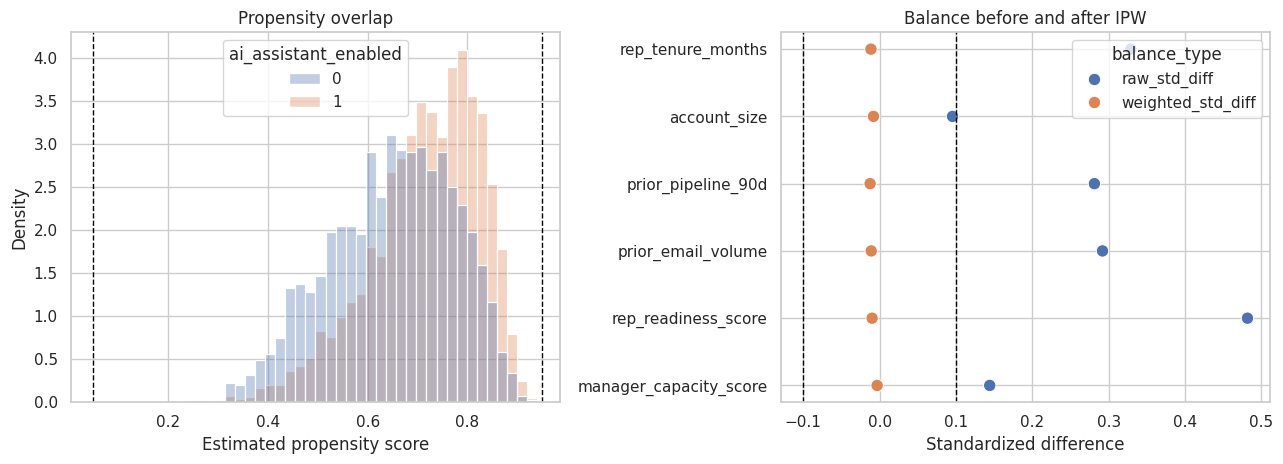

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.histplot(
    data=df_capstone,
    x='propensity',
    hue='ai_assistant_enabled',
    bins=35,
    stat='density',
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)
axes[0].axvline(0.05, color='black', linestyle='--', linewidth=1)
axes[0].axvline(0.95, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Propensity overlap')
axes[0].set_xlabel('Estimated propensity score')

balance_plot = balance_table.melt(
    id_vars='variable',
    value_vars=['raw_std_diff', 'weighted_std_diff'],
    var_name='balance_type',
    value_name='std_diff',
)
sns.scatterplot(data=balance_plot, x='std_diff', y='variable', hue='balance_type', s=80, ax=axes[1])
axes[1].axvline(-0.10, color='black', linestyle='--', linewidth=1)
axes[1].axvline(0.10, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Balance before and after IPW')
axes[1].set_xlabel('Standardized difference')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 7. Effect Estimation

We compare multiple estimators. Agreement among plausible estimators is not proof, but disagreement is a warning.

In [13]:
def fit_ols_effect(outcome, treatment='ai_assistant_enabled', covariates=adjustment_set, data=df_capstone):
    formula = f"{outcome} ~ {treatment} + {rhs(covariates)}"
    model = smf.ols(formula, data=data).fit(cov_type='HC1')
    return {
        'method': 'regression_adjustment',
        'outcome': outcome,
        'formula': formula,
        'estimate': float(model.params[treatment]),
        'std_error': float(model.bse[treatment]),
        'ci_low': float(model.conf_int().loc[treatment, 0]),
        'ci_high': float(model.conf_int().loc[treatment, 1]),
        'p_value': float(model.pvalues[treatment]),
    }


def estimate_ipw(outcome, treatment='ai_assistant_enabled', data=df_capstone):
    t = data[treatment]
    y = data[outcome]
    p = data['propensity']
    return float((t * y / p - (1 - t) * y / (1 - p)).mean())


def estimate_aipw(outcome, treatment='ai_assistant_enabled', covariates=adjustment_set, data=df_capstone):
    treated = data[data[treatment] == 1]
    control = data[data[treatment] == 0]
    m1 = smf.ols(f"{outcome} ~ {rhs(covariates)}", data=treated).fit()
    m0 = smf.ols(f"{outcome} ~ {rhs(covariates)}", data=control).fit()
    mu1 = m1.predict(data)
    mu0 = m0.predict(data)
    t = data[treatment]
    y = data[outcome]
    p = data['propensity']
    return float((mu1 - mu0 + t * (y - mu1) / p - (1 - t) * (y - mu0) / (1 - p)).mean())


primary_reg = fit_ols_effect('qualified_pipeline_created')
primary_ipw = {'method': 'ipw', 'outcome': 'qualified_pipeline_created', 'estimate': estimate_ipw('qualified_pipeline_created')}
primary_aipw = {'method': 'aipw', 'outcome': 'qualified_pipeline_created', 'estimate': estimate_aipw('qualified_pipeline_created')}
naive_primary = {'method': 'naive_difference', 'outcome': 'qualified_pipeline_created', 'estimate': naive_effect}
bad_control_reg = fit_ols_effect('qualified_pipeline_created', covariates=adjustment_set + ['ai_messages_generated_after_enablement'])
bad_control_reg['method'] = 'bad_control_regression'
truth_primary = {'method': 'true_expected_ate_synthetic_only', 'outcome': 'qualified_pipeline_created', 'estimate': true_ate}

estimate_table = pd.DataFrame([naive_primary, primary_reg, primary_ipw, primary_aipw, bad_control_reg, truth_primary])
estimate_table

,method,outcome,estimate,formula,std_error,ci_low,ci_high,p_value
0,naive_difference,qualified_pipeline_created,0.115851,NaN,NaN,NaN,NaN,NaN
1,regression_adjustment,qualified_pipeline_created,0.075234,qualified_pipeline_created ~ ai_assistant_enab...,0.012127,0.051465,0.099003,5.513806e-10
2,ipw,qualified_pipeline_created,0.072116,NaN,NaN,NaN,NaN,NaN
3,aipw,qualified_pipeline_created,0.076967,NaN,NaN,NaN,NaN,NaN
4,bad_control_regression,qualified_pipeline_created,0.076791,qualified_pipeline_created ~ ai_assistant_enab...,0.024363,0.029040,0.124542,1.621961e-03
5,true_expected_ate_synthetic_only,qualified_pipeline_created,0.076648,NaN,NaN,NaN,NaN,NaN


In [14]:
guardrail_rows = []
for outcome in ['pipeline_value_30d', 'customer_complaint_30d', 'discount_rate_30d']:
    result = fit_ols_effect(outcome)
    result['method'] = 'regression_adjustment_guardrail'
    guardrail_rows.append(result)

guardrail_table = pd.DataFrame(guardrail_rows)
guardrail_table[['outcome', 'estimate', 'ci_low', 'ci_high', 'p_value']]

,outcome,estimate,ci_low,ci_high,p_value
0,pipeline_value_30d,59.356730,55.032083,63.681377,2.141618e-159
1,customer_complaint_30d,0.038365,0.027389,0.049341,7.341392e-12
2,discount_rate_30d,0.010848,0.009009,0.012687,6.480247e-31


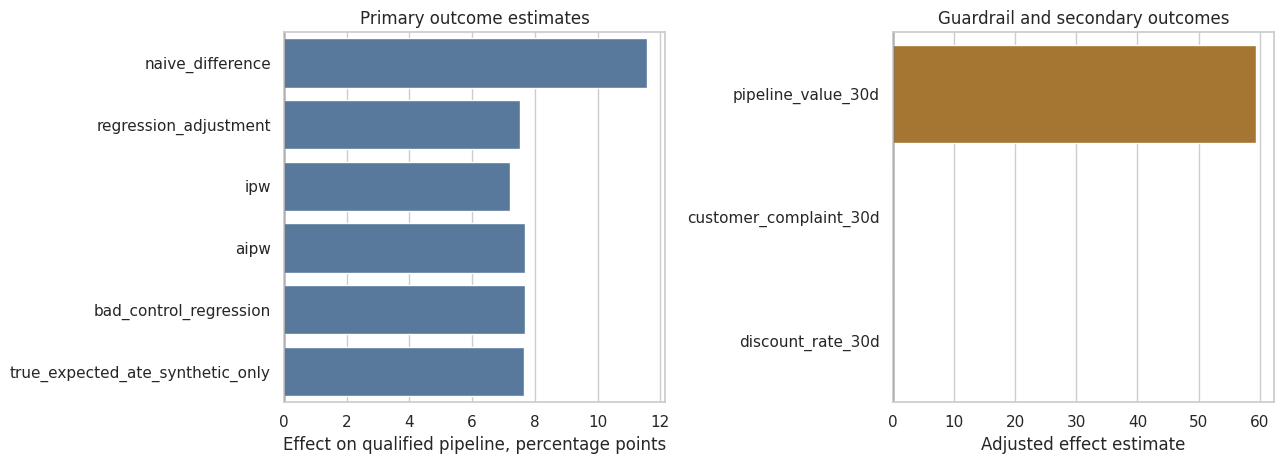

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

plot_estimates = estimate_table.copy()
plot_estimates['estimate_pp'] = 100 * plot_estimates['estimate']
sns.barplot(data=plot_estimates, x='estimate_pp', y='method', color='#4C78A8', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Primary outcome estimates')
axes[0].set_xlabel('Effect on qualified pipeline, percentage points')
axes[0].set_ylabel('')

sns.barplot(data=guardrail_table, x='estimate', y='outcome', color='#B7791F', ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Guardrail and secondary outcomes')
axes[1].set_xlabel('Adjusted effect estimate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 8. Sensitivity and Decision Gates

Sensitivity analysis here is deliberately simple: we ask how large an unobserved bias would need to be, relative to the preferred estimate, to erase the conclusion. In production, this should be replaced or supplemented with domain-specific sensitivity analysis.

In [16]:
def estimator_stability(estimate_table):
    plausible = estimate_table[estimate_table['method'].isin(['regression_adjustment', 'ipw', 'aipw'])]
    spread = plausible['estimate'].max() - plausible['estimate'].min()
    signs_consistent = plausible['estimate'].gt(0).all() or plausible['estimate'].lt(0).all()
    return {
        'plausible_methods': plausible[['method', 'estimate']].to_dict(orient='records'),
        'spread_pp': float(100 * spread),
        'signs_consistent': bool(signs_consistent),
        'status': 'pass' if signs_consistent and spread < 0.04 else 'review',
    }


def simple_tipping_point(preferred_estimate, bias_grid=None):
    if bias_grid is None:
        bias_grid = np.linspace(0, 0.08, 41)
    rows = []
    for bias in bias_grid:
        adjusted = preferred_estimate - bias
        rows.append({'hypothetical_unobserved_bias': bias, 'bias_adjusted_effect': adjusted, 'sign_positive': adjusted > 0})
    return pd.DataFrame(rows)


stability = estimator_stability(estimate_table)
preferred_estimate = float(estimate_table.loc[estimate_table['method'] == 'aipw', 'estimate'].iloc[0])
tipping_table = simple_tipping_point(preferred_estimate)
minimum_bias_to_zero = tipping_table.loc[~tipping_table['sign_positive'], 'hypothetical_unobserved_bias'].min()

sensitivity_summary = {
    'preferred_estimator': 'aipw',
    'preferred_estimate_pp': 100 * preferred_estimate,
    'minimum_unobserved_bias_to_reverse_pp': None if pd.isna(minimum_bias_to_zero) else float(100 * minimum_bias_to_zero),
    'stability': stability,
}
print(json.dumps(sensitivity_summary, indent=2))

{
  "preferred_estimator": "aipw",
  "preferred_estimate_pp": 7.696702847666442,
  "minimum_unobserved_bias_to_reverse_pp": 7.8,
  "stability": {
    "plausible_methods": [
      {
        "method": "regression_adjustment",
        "estimate": 0.07523439332293363
      },
      {
        "method": "ipw",
        "estimate": 0.07211628814707559
      },
      {
        "method": "aipw",
        "estimate": 0.07696702847666442
      }
    ],
    "spread_pp": 0.48507403295888346,
    "signs_consistent": true,
    "status": "pass"
  }
}


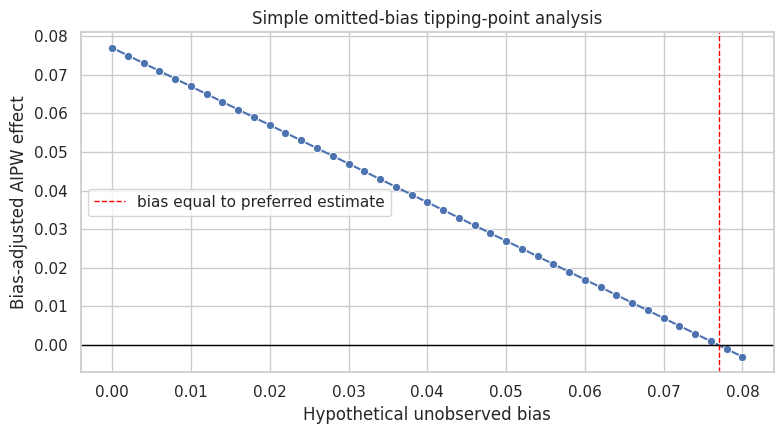

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=tipping_table, x='hypothetical_unobserved_bias', y='bias_adjusted_effect', marker='o', ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(preferred_estimate, color='red', linestyle='--', linewidth=1, label='bias equal to preferred estimate')
ax.set_title('Simple omitted-bias tipping-point analysis')
ax.set_xlabel('Hypothetical unobserved bias')
ax.set_ylabel('Bias-adjusted AIPW effect')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
def build_gate_table():
    gates = [
        {
            'gate': 'design matches assignment process',
            'status': 'pass' if estimand_card['design_class'] == 'observational_adjustment' else 'fail',
            'reason': 'Enablement was targeted, not randomized.',
        },
        {
            'gate': 'no post-treatment controls in preferred adjustment set',
            'status': 'pass' if not set(adjustment_set).intersection(post_treatment_variables) else 'fail',
            'reason': f'post-treatment variables excluded: {post_treatment_variables}',
        },
        {
            'gate': 'overlap adequate',
            'status': overlap['status'],
            'reason': f"share in [0.05, 0.95] = {overlap['share_between_05_95']:.3f}",
        },
        {
            'gate': 'weighted balance acceptable',
            'status': 'pass' if balance_table['weighted_std_diff'].abs().max() <= 0.10 else 'review',
            'reason': f"max weighted abs std diff = {balance_table['weighted_std_diff'].abs().max():.3f}",
        },
        {
            'gate': 'plausible estimators stable',
            'status': stability['status'],
            'reason': f"spread = {stability['spread_pp']:.2f} pp",
        },
        {
            'gate': 'guardrails reviewed',
            'status': 'review' if guardrail_table.query("outcome == 'customer_complaint_30d'")['ci_high'].iloc[0] > 0 else 'pass',
            'reason': 'Customer complaint and discount guardrails require rollout monitoring.',
        },
    ]
    return pd.DataFrame(gates)


gate_table = build_gate_table()
gate_table

,gate,status,reason
0,design matches assignment process,pass,"Enablement was targeted, not randomized."
1,no post-treatment controls in preferred adjust...,pass,post-treatment variables excluded: ['ai_messag...
2,overlap adequate,pass,"share in [0.05, 0.95] = 1.000"
3,weighted balance acceptable,pass,max weighted abs std diff = 0.012
4,plausible estimators stable,pass,spread = 0.49 pp
5,guardrails reviewed,review,Customer complaint and discount guardrails req...


## 9. Evidence Package and Deterministic Report

The evidence package is what AI systems are allowed to summarize. They should not invent diagnostics, sources, or stronger claims.

In [19]:
def clean_value(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        if np.isnan(value):
            return None
        return float(value)
    if isinstance(value, dict):
        return {key: clean_value(val) for key, val in value.items() if clean_value(val) is not None}
    if isinstance(value, list):
        return [clean_value(item) for item in value]
    return value


def records(dataframe):
    return clean_value(dataframe.to_dict(orient='records'))


evidence_package = clean_value({
    'project_brief': project_brief,
    'estimand_card': estimand_card,
    'variable_dictionary': records(variable_dictionary),
    'overlap': overlap,
    'balance_table': records(balance_table.round(4)),
    'estimate_table': records(estimate_table.round(5)),
    'guardrail_table': records(guardrail_table[['outcome', 'estimate', 'ci_low', 'ci_high', 'p_value']].round(5)),
    'sensitivity_summary': sensitivity_summary,
    'gate_table': records(gate_table),
    'approved_claim_boundary': 'Observed adjusted evidence suggests a positive effect on qualified pipeline, but assignment was targeted and rollout should require human review plus guardrail monitoring.',
    'brittleness_note': 'This capstone combines deterministic analysis and LLM outputs; model outputs can vary across reruns and must be audited.',
})

print(json.dumps(evidence_package, indent=2)[:5200])

{
  "project_brief": {
    "project_id": "ai_sales_assistant_capstone_v1",
    "decision": "Should the company expand the AI sales assistant to all eligible sales reps?",
    "unit": "rep_account_month",
    "treatment": "ai_assistant_enabled",
    "primary_outcome": "qualified_pipeline_created",
    "secondary_outcome": "pipeline_value_30d",
    "guardrail_outcomes": [
      "customer_complaint_30d",
      "discount_rate_30d"
    ],
    "time_horizon": "30 days after account-month eligibility",
    "assignment_process": "Managers enabled the assistant first for reps with high readiness, high-volume accounts, and available onboarding capacity.",
    "known_risks": [
      "Enablement was targeted rather than randomized.",
      "AI activity metrics after enablement are post-treatment variables.",
      "Revenue-facing outcomes can move with seasonality and account mix.",
      "Expansion may increase discounting or customer complaints."
    ]
  },
  "estimand_card": {
    "project_id":

In [20]:
def build_deterministic_capstone_report(package):
    preferred = next(row for row in package['estimate_table'] if row['method'] == 'aipw')
    reg = next(row for row in package['estimate_table'] if row['method'] == 'regression_adjustment')
    gates = pd.DataFrame(package['gate_table'])
    gate_lines = '\n'.join(f"- {row.gate}: {row.status} ({row.reason})" for row in gates.itertuples())
    complaint = next(row for row in package['guardrail_table'] if row['outcome'] == 'customer_complaint_30d')
    discount = next(row for row in package['guardrail_table'] if row['outcome'] == 'discount_rate_30d')
    return f"""
### Capstone Causal Report: AI Sales Assistant

**Decision.** {package['project_brief']['decision']}

**Design.** Observational adjustment. Enablement was targeted by readiness and capacity, so this is not randomized evidence.

**Estimand.** {package['estimand_card']['estimand']}

**Primary estimate.** The preferred AIPW estimate is {100 * preferred['estimate']:.1f} percentage points on qualified pipeline creation. Regression adjustment gives {100 * reg['estimate']:.1f} percentage points with 95% CI {100 * reg['ci_low']:.1f} to {100 * reg['ci_high']:.1f} percentage points.

**Diagnostics.**
{gate_lines}

**Guardrails.** Customer complaints changed by {100 * complaint['estimate']:.2f} percentage points. Discount rate changed by {100 * discount['estimate']:.2f} percentage points. Both should be monitored in any phased rollout.

**Recommendation.** Proceed only with human review and a monitored phased rollout. Do not claim the AI assistant was randomized, and do not control for post-enablement AI message volume when estimating the total effect.

**Brittleness note.** AI-generated summaries of this evidence can change across reruns and model families; use the structured gates and redline checks before sharing with stakeholders.
""".strip()


capstone_report = build_deterministic_capstone_report(evidence_package)
display(Markdown(capstone_report))

### Capstone Causal Report: AI Sales Assistant

**Decision.** Should the company expand the AI sales assistant to all eligible sales reps?

**Design.** Observational adjustment. Enablement was targeted by readiness and capacity, so this is not randomized evidence.

**Estimand.** Average effect of enabling the AI sales assistant on qualified pipeline creation among eligible rep-account-months

**Primary estimate.** The preferred AIPW estimate is 7.7 percentage points on qualified pipeline creation. Regression adjustment gives 7.5 percentage points with 95% CI 5.1 to 9.9 percentage points.

**Diagnostics.**
- design matches assignment process: pass (Enablement was targeted, not randomized.)
- no post-treatment controls in preferred adjustment set: pass (post-treatment variables excluded: ['ai_messages_generated_after_enablement', 'qualified_pipeline_created', 'pipeline_value_30d', 'customer_complaint_30d', 'discount_rate_30d'])
- overlap adequate: pass (share in [0.05, 0.95] = 1.000)
- weighted balance acceptable: pass (max weighted abs std diff = 0.012)
- plausible estimators stable: pass (spread = 0.49 pp)
- guardrails reviewed: review (Customer complaint and discount guardrails require rollout monitoring.)

**Guardrails.** Customer complaints changed by 3.84 percentage points. Discount rate changed by 1.08 percentage points. Both should be monitored in any phased rollout.

**Recommendation.** Proceed only with human review and a monitored phased rollout. Do not claim the AI assistant was randomized, and do not control for post-enablement AI message volume when estimating the total effect.

**Brittleness note.** AI-generated summaries of this evidence can change across reruns and model families; use the structured gates and redline checks before sharing with stakeholders.

## 10. AI Output Schema and Prompt

The capstone LLM task is not to redo the analysis. It is to review and summarize the evidence package with explicit constraints.

In [21]:
class CapstoneCausalReview(BaseModel):
    title: str
    design_assessment: str
    estimand_assessment: str
    diagnostic_summary: list[str] = Field(min_length=3)
    primary_result_summary: str
    guardrail_summary: list[str] = Field(min_length=2)
    risks_and_limitations: list[str] = Field(min_length=3)
    forbidden_claims: list[str] = Field(min_length=2)
    recommendation: Literal['roll_out', 'phase_rollout_with_monitoring', 'needs_more_analysis', 'do_not_roll_out']
    recommendation_rationale: list[str] = Field(min_length=2)
    human_review_gates: list[str] = Field(default_factory=list)
    brittleness_note: str
    confidence: Literal['low', 'medium', 'high']


REVIEW_FIELD_ALIASES = {
    'summary': 'primary_result_summary',
    'design': 'design_assessment',
    'estimand': 'estimand_assessment',
    'diagnostics': 'diagnostic_summary',
    'guardrails': 'guardrail_summary',
    'risks': 'risks_and_limitations',
    'limitations': 'risks_and_limitations',
    'do_not_claim': 'forbidden_claims',
    'recommendation_reasoning': 'recommendation_rationale',
    'gates': 'human_review_gates',
}

REVIEW_VALUE_ALIASES = {
    'recommendation': {
        'phased rollout': 'phase_rollout_with_monitoring',
        'phase rollout': 'phase_rollout_with_monitoring',
        'roll out with monitoring': 'phase_rollout_with_monitoring',
        'needs analysis': 'needs_more_analysis',
        'needs more analysis': 'needs_more_analysis',
        'do not rollout': 'do_not_roll_out',
        'do not roll out': 'do_not_roll_out',
    },
    'confidence': {'moderate': 'medium', 'cautious': 'medium', 'uncertain': 'low'},
}

REVIEW_DEFAULTS = {
    'title': 'Capstone causal review',
    'design_assessment': '',
    'estimand_assessment': '',
    'diagnostic_summary': [],
    'primary_result_summary': '',
    'guardrail_summary': [],
    'risks_and_limitations': [],
    'forbidden_claims': [],
    'recommendation': 'needs_more_analysis',
    'recommendation_rationale': [],
    'human_review_gates': [],
    'brittleness_note': '',
    'confidence': 'medium',
}

In [22]:
CAPSTONE_SYSTEM_MESSAGE = """
You are a careful causal inference reviewer for an AI-assisted causal project.
Use only the evidence package. Do not invent diagnostics, columns, or sources. Return final JSON only.
""".strip()


def capstone_schema_prompt():
    return """
Return one CapstoneCausalReview JSON object only.

Schema:
{
  "title": "string",
  "design_assessment": "string",
  "estimand_assessment": "string",
  "diagnostic_summary": ["string", "string", "string"],
  "primary_result_summary": "string",
  "guardrail_summary": ["string", "string"],
  "risks_and_limitations": ["string", "string", "string"],
  "forbidden_claims": ["string", "string"],
  "recommendation": "roll_out | phase_rollout_with_monitoring | needs_more_analysis | do_not_roll_out",
  "recommendation_rationale": ["string", "string"],
  "human_review_gates": ["string"],
  "brittleness_note": "string",
  "confidence": "low | medium | high"
}
""".strip()


def build_capstone_prompt(package):
    return f"""
{capstone_schema_prompt()}

Evidence package:
{json.dumps(package, indent=2)}

Requirements:
- State that this is observational adjustment, not randomized evidence.
- Mention the post-treatment AI message variable as a forbidden adjustment variable.
- Mention overlap, balance, estimator stability, guardrails, and sensitivity.
- Recommend only what the evidence supports.
- Mention brittleness and the need to audit model-generated summaries.
""".strip()


capstone_prompt = build_capstone_prompt(evidence_package)
print(capstone_prompt[:3000])

Return one CapstoneCausalReview JSON object only.

Schema:
{
  "title": "string",
  "design_assessment": "string",
  "estimand_assessment": "string",
  "diagnostic_summary": ["string", "string", "string"],
  "primary_result_summary": "string",
  "guardrail_summary": ["string", "string"],
  "risks_and_limitations": ["string", "string", "string"],
  "forbidden_claims": ["string", "string"],
  "recommendation": "roll_out | phase_rollout_with_monitoring | needs_more_analysis | do_not_roll_out",
  "recommendation_rationale": ["string", "string"],
  "human_review_gates": ["string"],
  "brittleness_note": "string",
  "confidence": "low | medium | high"
}

Evidence package:
{
  "project_brief": {
    "project_id": "ai_sales_assistant_capstone_v1",
    "decision": "Should the company expand the AI sales assistant to all eligible sales reps?",
    "unit": "rep_account_month",
    "treatment": "ai_assistant_enabled",
    "primary_outcome": "qualified_pipeline_created",
    "secondary_outcome": "p

In [23]:
try:
    from notebooks._shared.local_llm import clear_loaded_model_cache, local_chat
    from notebooks._shared.structured_outputs import parse_pydantic_output
except Exception as exc:
    clear_loaded_model_cache = None
    local_chat = None
    parse_pydantic_output = None
    print(f'Could not import shared LLM helpers: {exc}')


def release_model_memory():
    if clear_loaded_model_cache is None:
        return
    try:
        clear_loaded_model_cache()
    except Exception as exc:
        print(f'Could not clear loaded model cache: {exc}')

In [24]:
def parse_capstone_review(raw_output):
    if parse_pydantic_output is None:
        raise RuntimeError('parse_pydantic_output is unavailable')
    return parse_pydantic_output(
        raw_output,
        CapstoneCausalReview,
        scalar_fields=['title', 'design_assessment', 'estimand_assessment', 'primary_result_summary', 'recommendation', 'brittleness_note', 'confidence'],
        list_fields=['diagnostic_summary', 'guardrail_summary', 'risks_and_limitations', 'forbidden_claims', 'recommendation_rationale', 'human_review_gates'],
        field_aliases=REVIEW_FIELD_ALIASES,
        value_aliases=REVIEW_VALUE_ALIASES,
        defaults=REVIEW_DEFAULTS,
    )


raw_capstone_review = None
parsed_capstone_review = None
capstone_parse_error = None

if RUN_LIVE_LOCAL_LLM and local_chat is not None and parse_pydantic_output is not None:
    release_model_memory()
    try:
        raw_capstone_review = local_chat(
            capstone_prompt,
            system_message=CAPSTONE_SYSTEM_MESSAGE,
            model_id=MODEL_ID,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
            seed=SEED,
            enabled=RUN_LIVE_LOCAL_LLM,
        )
        print(raw_capstone_review[:3500])
        try:
            parsed = parse_capstone_review(raw_capstone_review)
            parsed_capstone_review = parsed.parsed
            if parsed.notes:
                print('Parser notes:', parsed.notes)
        except Exception as exc:
            capstone_parse_error = exc
            print(f'Parsing failed: {exc}')
    finally:
        release_model_memory()
else:
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local capstone review.')

{
 "title": "Capstone Review for AI Sales Assistant Expansion",
 "design_assessment": "The design is observational adjustment, not randomized evidence. The assignment process was targeted based on manager decisions, which introduces potential biases.",
 "estimand_assessment": "The estimand is the average effect of enabling the AI sales assistant on qualified pipeline creation among eligible rep-account-months, compared to the same units without the assistant. This requires conditional exchangeability after observed pre-treatment adjustment.",
 "diagnostic_summary": [
 "Overlap is adequate with all units having sufficient propensity scores within the range [0.05, 0.95].",
 "Weighted balance is acceptable, with all covariates achieving satisfactory balance after weighting.",
 "Estimator stability is confirmed with consistent signs across plausible methods and a small spread of estimates."
 ],
 "primary_result_summary": "The preferred estimate using augmented inverse probability weighting

In [25]:
if parsed_capstone_review is not None:
    display(Markdown(f"### {parsed_capstone_review.title}"))
    display(Markdown(parsed_capstone_review.design_assessment))
    display(Markdown('**Diagnostics**\n' + '\n'.join(f'- {item}' for item in parsed_capstone_review.diagnostic_summary)))
    display(Markdown(f'**Recommendation:** `{parsed_capstone_review.recommendation}`  \n**Confidence:** `{parsed_capstone_review.confidence}`'))
else:
    print('No parsed capstone review is available yet.')

### Capstone Review for AI Sales Assistant Expansion

The design is observational adjustment, not randomized evidence. The assignment process was targeted based on manager decisions, which introduces potential biases.

**Diagnostics**
- Overlap is adequate with all units having sufficient propensity scores within the range [0.05, 0.95].
- Weighted balance is acceptable, with all covariates achieving satisfactory balance after weighting.
- Estimator stability is confirmed with consistent signs across plausible methods and a small spread of estimates.

**Recommendation:** `phase_rollout_with_monitoring`  
**Confidence:** `medium`

## 11. Auditing the AI Capstone Review

The audit checks for the highest-risk capstone failures: randomized overclaiming, bad-control omission, missing guardrails, and missing brittleness.

In [26]:
def contains_any(text, patterns):
    text_lower = text.lower()
    return any(pattern.lower() in text_lower for pattern in patterns)


def score_capstone_review(review):
    if review is None:
        return pd.DataFrame([{'criterion': 'parsed review exists', 'passed': False, 'score': 0}])
    text = ' '.join([
        review.title,
        review.design_assessment,
        review.estimand_assessment,
        ' '.join(review.diagnostic_summary),
        review.primary_result_summary,
        ' '.join(review.guardrail_summary),
        ' '.join(review.risks_and_limitations),
        ' '.join(review.forbidden_claims),
        review.recommendation,
        ' '.join(review.recommendation_rationale),
        ' '.join(review.human_review_gates),
        review.brittleness_note,
        review.confidence,
    ]).lower()
    checks = {
        'states observational not randomized': contains_any(text, ['observational', 'not randomized', 'targeted']) and not contains_any(text, ['randomized evidence', 'randomized experiment']),
        'mentions forbidden post-treatment AI message variable': contains_any(text, ['ai_messages_generated_after_enablement', 'post-treatment', 'post enablement', 'bad control']),
        'mentions overlap and balance': contains_any(text, ['overlap']) and contains_any(text, ['balance']),
        'mentions estimator stability or sensitivity': contains_any(text, ['stability', 'sensitivity', 'aipw', 'ipw']),
        'mentions guardrails': contains_any(text, ['complaint', 'discount', 'guardrail']),
        'recommendation is not unconditional rollout': review.recommendation in {'phase_rollout_with_monitoring', 'needs_more_analysis', 'do_not_roll_out'},
        'mentions human review gates': len(review.human_review_gates) >= 1 or contains_any(text, ['human review']),
        'mentions brittleness or audit': contains_any(text, ['brittle', 'rerun', 'audit', 'model output', 'unstable']),
        'does not use proof language': not contains_any(text, ['proves', 'guarantees', 'definitively']),
        'forbidden claims included': len(review.forbidden_claims) >= 2,
    }
    return pd.DataFrame([
        {'criterion': key, 'passed': bool(value), 'score': int(bool(value))}
        for key, value in checks.items()
    ])


capstone_review_score = score_capstone_review(parsed_capstone_review)
capstone_review_score

,criterion,passed,score
0,states observational not randomized,False,0
1,mentions forbidden post-treatment AI message v...,True,1
2,mentions overlap and balance,True,1
3,mentions estimator stability or sensitivity,True,1
4,mentions guardrails,True,1
5,recommendation is not unconditional rollout,True,1
6,mentions human review gates,True,1
7,mentions brittleness or audit,True,1
8,does not use proof language,True,1
9,forbidden claims included,True,1


## 12. Redline Rules for the Final Report

Even if the structured review parses, the final report should be redlined before stakeholder use.

In [27]:
REDLINE_PATTERNS = {
    'randomization overclaim': r'\b(randomized experiment|randomized evidence|random assignment)\b',
    'proof language': r'\b(proves?|guarantees?|definitively)\b',
    'bad-control reassurance': r'\bcontrol\w*\b.{0,80}\b(ai_messages_generated_after_enablement|messages generated|post-enablement)\b',
    'unconditional rollout': r'\b(roll out to all|full rollout|expand to all)\b',
}


def redline_text(text):
    rows = []
    for issue, pattern in REDLINE_PATTERNS.items():
        for match in re.finditer(pattern, text, flags=re.IGNORECASE):
            start, end = match.span()
            snippet = text[max(0, start - 80): min(len(text), end + 80)].replace('\n', ' ')
            rows.append({'issue': issue, 'match': match.group(0), 'snippet': snippet})
    return pd.DataFrame(rows)


redline_text(capstone_report)

,issue,match,snippet
0,randomization overclaim,randomized evidence,l adjustment. Enablement was targeted by readi...
1,bad-control reassurance,controls in preferred adjustment set: pass (po...,"nt process: pass (Enablement was targeted, not..."
2,bad-control reassurance,control for post-enablement,itored phased rollout. Do not claim the AI ass...


## 13. Optional All-Model Capstone Comparison

The comparison uses compact cases based on the capstone. Each model must produce a decision and identify the blockers. We clear model memory between model families.

In [28]:
class CompactCapstoneDecision(BaseModel):
    decision: Literal['roll_out', 'phase_rollout_with_monitoring', 'needs_more_analysis', 'do_not_roll_out']
    design_label: Literal['randomized_experiment', 'observational_adjustment', 'difference_in_differences', 'do_not_analyze_yet']
    blockers: list[str] = Field(default_factory=list)
    required_diagnostics: list[str] = Field(default_factory=list)
    forbidden_adjustments: list[str] = Field(default_factory=list)
    guardrails_to_monitor: list[str] = Field(default_factory=list)
    brittleness_note: str
    confidence: Literal['low', 'medium', 'high']


COMPACT_FIELD_ALIASES = {
    'recommendation': 'decision',
    'design': 'design_label',
    'risks': 'blockers',
    'diagnostics': 'required_diagnostics',
    'excluded_variables': 'forbidden_adjustments',
    'guardrails': 'guardrails_to_monitor',
}

COMPACT_VALUE_ALIASES = {
    'decision': REVIEW_VALUE_ALIASES['recommendation'],
    'design_label': {
        'observational': 'observational_adjustment',
        'observational adjustment': 'observational_adjustment',
        'randomized': 'randomized_experiment',
        'experiment': 'randomized_experiment',
        'did': 'difference_in_differences',
        'do not analyze': 'do_not_analyze_yet',
    },
    'confidence': REVIEW_VALUE_ALIASES['confidence'],
}

COMPACT_DEFAULTS = {
    'decision': 'needs_more_analysis',
    'design_label': 'observational_adjustment',
    'blockers': [],
    'required_diagnostics': [],
    'forbidden_adjustments': [],
    'guardrails_to_monitor': [],
    'brittleness_note': '',
    'confidence': 'medium',
}

In [29]:
CAPSTONE_EVAL_CASES = [
    {
        'case_name': 'targeted_ai_sales_assistant',
        'brief': 'Managers targeted AI sales assistant enablement to high-readiness reps. There is a post-treatment variable ai_messages_generated_after_enablement.',
        'expected_design': 'observational_adjustment',
        'expected_decision': 'phase_rollout_with_monitoring',
        'must_exclude': ['ai_messages_generated_after_enablement'],
        'must_monitor': ['customer_complaint_30d', 'discount_rate_30d'],
    },
    {
        'case_name': 'randomized_ai_holdout',
        'brief': 'Eligible reps were randomly assigned to AI assistant enablement with a 20% holdout. Guardrails include complaint rate and discounting.',
        'expected_design': 'randomized_experiment',
        'expected_decision': 'phase_rollout_with_monitoring',
        'must_exclude': [],
        'must_monitor': ['complaint rate', 'discounting'],
    },
    {
        'case_name': 'post_treatment_only_metrics',
        'brief': 'The only available predictors are AI messages generated after enablement and pipeline outcome. The team asks for a causal rollout recommendation.',
        'expected_design': 'do_not_analyze_yet',
        'expected_decision': 'do_not_roll_out',
        'must_exclude': ['AI messages generated after enablement'],
        'must_monitor': [],
    },
]

CAPSTONE_EVAL_CASES

[{'case_name': 'targeted_ai_sales_assistant',
  'brief': 'Managers targeted AI sales assistant enablement to high-readiness reps. There is a post-treatment variable ai_messages_generated_after_enablement.',
  'expected_design': 'observational_adjustment',
  'expected_decision': 'phase_rollout_with_monitoring',
  'must_exclude': ['ai_messages_generated_after_enablement'],
  'must_monitor': ['customer_complaint_30d', 'discount_rate_30d']},
 {'case_name': 'randomized_ai_holdout',
  'brief': 'Eligible reps were randomly assigned to AI assistant enablement with a 20% holdout. Guardrails include complaint rate and discounting.',
  'expected_design': 'randomized_experiment',
  'expected_decision': 'phase_rollout_with_monitoring',
  'must_exclude': [],
  'must_monitor': ['complaint rate', 'discounting']},
 {'case_name': 'post_treatment_only_metrics',
  'brief': 'The only available predictors are AI messages generated after enablement and pipeline outcome. The team asks for a causal rollout rec

In [30]:
def compact_capstone_prompt(case):
    return f"""
Return one CompactCapstoneDecision JSON object only.

Schema:
{{
  "decision": "roll_out | phase_rollout_with_monitoring | needs_more_analysis | do_not_roll_out",
  "design_label": "randomized_experiment | observational_adjustment | difference_in_differences | do_not_analyze_yet",
  "blockers": ["string"],
  "required_diagnostics": ["string"],
  "forbidden_adjustments": ["string"],
  "guardrails_to_monitor": ["string"],
  "brittleness_note": "string",
  "confidence": "low | medium | high"
}}

Case:
{json.dumps(case, indent=2)}

Rules:
- Do not call targeted enablement randomized.
- Exclude post-treatment AI activity variables from total-effect adjustment.
- Be conservative about rollout recommendations.
- Mention brittleness or audit of model-generated causal summaries.
""".strip()


def parse_compact_decision(raw_output):
    if parse_pydantic_output is None:
        raise RuntimeError('parse_pydantic_output is unavailable')
    return parse_pydantic_output(
        raw_output,
        CompactCapstoneDecision,
        scalar_fields=['decision', 'design_label', 'brittleness_note', 'confidence'],
        list_fields=['blockers', 'required_diagnostics', 'forbidden_adjustments', 'guardrails_to_monitor'],
        field_aliases=COMPACT_FIELD_ALIASES,
        value_aliases=COMPACT_VALUE_ALIASES,
        defaults=COMPACT_DEFAULTS,
    )


def score_compact_decision(decision, case):
    text = ' '.join([
        decision.decision,
        decision.design_label,
        ' '.join(decision.blockers),
        ' '.join(decision.required_diagnostics),
        ' '.join(decision.forbidden_adjustments),
        ' '.join(decision.guardrails_to_monitor),
        decision.brittleness_note,
    ]).lower()
    checks = {
        'design matches expected': decision.design_label == case['expected_design'],
        'decision matches expected': decision.decision == case['expected_decision'],
        'must-exclude variables identified': all(var.lower() in text for var in case['must_exclude']),
        'guardrails mentioned': all(var.lower() in text for var in case['must_monitor']) if case['must_monitor'] else True,
        'mentions diagnostics': contains_any(text, ['overlap', 'balance', 'guardrail', 'randomization', 'sensitivity', 'diagnostic']),
        'mentions brittleness or audit': contains_any(text, ['brittle', 'audit', 'rerun', 'model output', 'unstable']),
        'does not overclaim rollout': decision.decision != 'roll_out',
    }
    return int(sum(checks.values())), checks

In [31]:
def run_all_model_capstone_comparison(models_to_compare=MODELS_TO_COMPARE, cases=CAPSTONE_EVAL_CASES):
    rows = []
    failures = []
    selected_cases = cases[:MODEL_COMPARISON_CASE_LIMIT]
    if local_chat is None or parse_pydantic_output is None:
        return pd.DataFrame(), [{'error': 'shared LLM helpers unavailable'}]

    for label, model_id, role in models_to_compare:
        release_model_memory()
        print(f'Running {label}: {model_id}')
        try:
            for case in selected_cases:
                try:
                    raw = local_chat(
                        compact_capstone_prompt(case),
                        system_message=CAPSTONE_SYSTEM_MESSAGE,
                        model_id=model_id,
                        max_new_tokens=COMPACT_MAX_NEW_TOKENS,
                        temperature=TEMPERATURE,
                        seed=SEED,
                        enabled=True,
                    )
                    parsed = parse_compact_decision(raw)
                    score, checks = score_compact_decision(parsed.parsed, case)
                    rows.append({
                        'model': label,
                        'model_id': model_id,
                        'role': role,
                        'case': case['case_name'],
                        'decision': parsed.parsed.decision,
                        'design_label': parsed.parsed.design_label,
                        'score': score,
                        'max_score': len(checks),
                        'failed_checks': ', '.join([key for key, passed in checks.items() if not passed]),
                        'parser_notes': '; '.join(parsed.notes),
                    })
                except Exception as exc:
                    failures.append({'model': label, 'model_id': model_id, 'case': case['case_name'], 'error': repr(exc)})
        finally:
            release_model_memory()
    return pd.DataFrame(rows), failures


if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    capstone_model_comparison, capstone_model_failures = run_all_model_capstone_comparison()
else:
    capstone_model_comparison = pd.DataFrame()
    capstone_model_failures = []
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct
Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct
Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct
Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct
Running Phi mini: microsoft/Phi-3.5-mini-instruct


[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Running Mistral 7B: mistralai/Mistral-7B-Instruct-v0.3
Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it
Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


In [32]:
if len(capstone_model_comparison):
    display(capstone_model_comparison.sort_values(['score', 'model', 'case'], ascending=[False, True, True]).reset_index(drop=True))
else:
    print('No capstone model-comparison results yet.')

if capstone_model_failures:
    display(pd.DataFrame(capstone_model_failures))
else:
    print('No failed model details because the full comparison was skipped or all calls parsed.')

,model,model_id,role,case,decision,design_label,score,max_score,failed_checks,parser_notes
0,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,randomized_ai_holdout,phase_rollout_with_monitoring,randomized_experiment,7,7,,Invalid JSON: expected value at line 1 column ...
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,targeted_ai_sales_assistant,phase_rollout_with_monitoring,observational_adjustment,7,7,,Invalid JSON: expected value at line 1 column ...
2,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,targeted_ai_sales_assistant,phase_rollout_with_monitoring,observational_adjustment,7,7,,
3,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,targeted_ai_sales_assistant,phase_rollout_with_monitoring,observational_adjustment,7,7,,
4,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,post_treatment_only_metrics,do_not_roll_out,do_not_analyze_yet,6,7,mentions diagnostics,Invalid JSON: expected value at line 1 column ...
5,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,randomized_ai_holdout,phase_rollout_with_monitoring,randomized_experiment,6,7,mentions diagnostics,Invalid JSON: expected value at line 1 column ...
6,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,targeted_ai_sales_assistant,phase_rollout_with_monitoring,observational_adjustment,6,7,mentions diagnostics,Invalid JSON: expected value at line 1 column ...
7,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,post_treatment_only_metrics,do_not_roll_out,do_not_analyze_yet,6,7,mentions diagnostics,
8,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,randomized_ai_holdout,phase_rollout_with_monitoring,randomized_experiment,6,7,mentions diagnostics,
9,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,targeted_ai_sales_assistant,phase_rollout_with_monitoring,observational_adjustment,6,7,mentions diagnostics,


No failed model details because the full comparison was skipped or all calls parsed.


In [33]:
if len(capstone_model_comparison):
    summary = (
        capstone_model_comparison
        .groupby(['model', 'model_id', 'role'], as_index=False)
        .agg(mean_score=('score', 'mean'), min_score=('score', 'min'), cases=('case', 'nunique'))
        .sort_values(['mean_score', 'min_score'], ascending=False)
    )
    display(summary)
else:
    print('No capstone model summary yet.')

,model,model_id,role,mean_score,min_score,cases
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,6.333333,6,3
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,6.000000,6,3
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,6.000000,6,3
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,6.000000,6,3
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,6.000000,6,3
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,6.000000,6,3
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,6.000000,5,3
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,6.000000,4,3
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,3.666667,3,3


## 14. Capstone Checklist

Use this as the final checklist for AI-assisted causal projects:

1. The project brief, treatment, outcome, and decision are explicit.
2. The estimand is written before model selection.
3. Variable timing is reviewed before adjustment.
4. Post-treatment variables are excluded from total-effect adjustment.
5. The design matches the assignment process.
6. Overlap and balance diagnostics are reported.
7. Multiple plausible estimators are compared.
8. Guardrails are analyzed before recommendations.
9. Sensitivity or tipping-point analysis is included.
10. AI outputs are structured, parsed, scored, redlined, and compared across models.
11. Human review gates are explicit.
12. Brittleness across reruns, prompts, and model families is treated as a product risk.

## 15. Capstone Exercises

1. Change the assignment process to a randomized holdout. Which parts of the workflow should simplify?
2. Make overlap poor by enabling only very high-readiness reps. Does the gate table block rollout?
3. Add a fairness guardrail across regions or segments.
4. Add an RAG-style source packet with domain notes and require the model to cite only those notes.
5. Run the all-model comparison and inspect which models miss the post-treatment AI usage variable.
6. Turn the deterministic gates into a reusable checklist for future portfolio projects.

## 16. Course Wrap-Up

This course started with local models and ended with an end-to-end causal workflow. The main lesson is not that AI can automate causal inference. The lesson is that AI can help with causal work when the workflow is structured, grounded, auditable, and humble about uncertainty.

The best AI-assisted causal projects keep the human causal owner in the loop, preserve intermediate artifacts, test model outputs, and treat brittleness as something to measure. That is the professional standard this capstone is trying to model.